# Phase 3 — Diagnostic Construction

This notebook develops candidate early-warning diagnostics using only the
pre-specified Momentum development case.

Development event:

- Factor: Momentum
- Objective collapse start: October 7, 2009

Candidate diagnostics:

1. Rolling skewness
2. Rolling excess kurtosis
3. Rolling autocorrelation of squared returns

All calculations are trailing and causal. Other factors and later Momentum
episodes are excluded from development.

The purpose of this notebook is to select and freeze:

- diagnostic definitions,
- rolling window length,
- historical-standardization method,
- warning direction,
- warning threshold, and
- any diagnostic-combination rule.

After these parameters are frozen, they must not be changed during holdout
testing.

In [22]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(
    "/content/drive/MyDrive/When_Do_Factor_Premia_Break"
)

PROCESSED = ROOT / "data" / "processed"
RESULTS = ROOT / "data" / "results"

RESULTS.mkdir(parents=True, exist_ok=True)

FACTOR_INPUT = PROCESSED / "factor_returns_daily.parquet"
COLLAPSE_EVENTS_INPUT = RESULTS / "collapse_events.csv"

print("Factor data:", FACTOR_INPUT)
print("Collapse events:", COLLAPSE_EVENTS_INPUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Factor data: /content/drive/MyDrive/When_Do_Factor_Premia_Break/data/processed/factor_returns_daily.parquet
Collapse events: /content/drive/MyDrive/When_Do_Factor_Premia_Break/data/results/collapse_events.csv


In [23]:
factors = pd.read_parquet(FACTOR_INPUT)

collapse_events = pd.read_csv(
    COLLAPSE_EVENTS_INPUT,
    parse_dates=[
        "collapse_start",
        "collapse_end",
    ],
)

print("Factor data shape:", factors.shape)
print("Collapse event count:", len(collapse_events))

assert isinstance(factors.index, pd.DatetimeIndex)
assert factors.index.is_unique
assert factors.index.is_monotonic_increasing
assert "MOM" in factors.columns

required_event_columns = {
    "factor",
    "collapse_start",
    "collapse_end",
    "duration_trading_days",
}

assert required_event_columns.issubset(
    collapse_events.columns
)

print("✓ Input files passed validation")

Factor data shape: (15833, 7)
Collapse event count: 87
✓ Input files passed validation


In [24]:
DEVELOPMENT_FACTOR = "MOM"
DEVELOPMENT_COLLAPSE_START = pd.Timestamp("2009-10-07")

development_event = collapse_events.loc[
    (collapse_events["factor"] == DEVELOPMENT_FACTOR)
    & (
        collapse_events["collapse_start"]
        == DEVELOPMENT_COLLAPSE_START
    )
].copy()

assert len(development_event) == 1, (
    "The expected Momentum development event was not found exactly once."
)

development_event

DEVELOPMENT_COLLAPSE_END = development_event[
    "collapse_end"
].iloc[0]

print(
    "Development collapse:",
    DEVELOPMENT_COLLAPSE_START.date(),
    "to",
    DEVELOPMENT_COLLAPSE_END.date(),
)

Development collapse: 2009-10-07 to 2009-12-31


In [25]:
DEVELOPMENT_SAMPLE_END = pd.Timestamp("2010-12-31")

momentum = (
    factors["MOM"]
    .loc[:DEVELOPMENT_SAMPLE_END]
    .dropna()
    .copy()
)

print("Development sample start:", momentum.index.min())
print("Development sample end:", momentum.index.max())
print("Observations:", len(momentum))

assert momentum.index.max() <= DEVELOPMENT_SAMPLE_END
assert momentum.index.max() < pd.Timestamp("2020-01-01")

print("✓ Later Momentum episodes are excluded")

Development sample start: 1963-07-01 00:00:00
Development sample end: 2010-12-31 00:00:00
Observations: 11959
✓ Later Momentum episodes are excluded


In [26]:
DIAGNOSTIC_WINDOW = 63
ZSCORE_REFERENCE_WINDOW = 252
WARNING_HORIZON = 126
WARNING_RESET_DAYS = 5

CANDIDATE_THRESHOLDS = [
    1.5,
    2.0,
    2.5,
]

DEVELOPMENT_SETTINGS = {
    "development_factor": DEVELOPMENT_FACTOR,
    "development_collapse_start": str(
        DEVELOPMENT_COLLAPSE_START.date()
    ),
    "development_sample_end": str(
        DEVELOPMENT_SAMPLE_END.date()
    ),
    "diagnostic_window": DIAGNOSTIC_WINDOW,
    "zscore_reference_window": ZSCORE_REFERENCE_WINDOW,
    "warning_horizon_days": WARNING_HORIZON,
    "warning_reset_days": WARNING_RESET_DAYS,
    "candidate_thresholds": CANDIDATE_THRESHOLDS,
}

DEVELOPMENT_SETTINGS

{'development_factor': 'MOM',
 'development_collapse_start': '2009-10-07',
 'development_sample_end': '2010-12-31',
 'diagnostic_window': 63,
 'zscore_reference_window': 252,
 'warning_horizon_days': 126,
 'warning_reset_days': 5,
 'candidate_thresholds': [1.5, 2.0, 2.5]}

In [27]:
def rolling_skewness(
    returns: pd.Series,
    window: int,
) -> pd.Series:
    """
    Calculate trailing sample skewness.

    The value at date t uses only returns dated t-window+1 through t.
    """
    return returns.rolling(
        window=window,
        min_periods=window,
    ).skew()

def rolling_excess_kurtosis(
    returns: pd.Series,
    window: int,
) -> pd.Series:
    """
    Calculate trailing Fisher excess kurtosis.

    A normal distribution has excess kurtosis near zero.
    """
    return returns.rolling(
        window=window,
        min_periods=window,
    ).kurt()

def lag_one_autocorrelation(
    values: np.ndarray,
) -> float:
    """
    Calculate lag-one autocorrelation for one complete rolling window.
    """
    values = np.asarray(values, dtype=float)

    if len(values) < 3:
        return np.nan

    lagged = values[:-1]
    current = values[1:]

    if (
        np.std(lagged, ddof=1) == 0
        or np.std(current, ddof=1) == 0
    ):
        return np.nan

    return float(
        np.corrcoef(
            lagged,
            current,
        )[0, 1]
    )

def rolling_squared_return_autocorrelation(
    returns: pd.Series,
    window: int,
) -> pd.Series:
    """
    Calculate trailing lag-one autocorrelation of squared returns.
    """
    squared_returns = returns.pow(2)

    return squared_returns.rolling(
        window=window,
        min_periods=window,
    ).apply(
        lag_one_autocorrelation,
        raw=True,
    )

In [28]:
def compute_rolling_diagnostic(
    returns: pd.Series,
    statistic: str,
    window: int,
) -> pd.Series:
    """
    Compute one supported trailing diagnostic.
    """
    supported_statistics = {
        "skewness",
        "excess_kurtosis",
        "squared_return_acf",
    }

    if statistic not in supported_statistics:
        raise ValueError(
            f"Unsupported statistic: {statistic}. "
            f"Choose from {sorted(supported_statistics)}."
        )

    if statistic == "skewness":
        output = rolling_skewness(
            returns,
            window,
        )

    elif statistic == "excess_kurtosis":
        output = rolling_excess_kurtosis(
            returns,
            window,
        )

    else:
        output = rolling_squared_return_autocorrelation(
            returns,
            window,
        )

    output.name = statistic

    return output

raw_diagnostics = pd.DataFrame(
    {
        diagnostic: compute_rolling_diagnostic(
            momentum,
            statistic=diagnostic,
            window=DIAGNOSTIC_WINDOW,
        )
        for diagnostic in [
            "skewness",
            "excess_kurtosis",
            "squared_return_acf",
        ]
    },
    index=momentum.index,
)

raw_diagnostics.dropna().head()

,skewness,excess_kurtosis,squared_return_acf
date,,,
1963-09-27,-0.114463,-0.392240,-0.114482
1963-09-30,-0.225179,-0.292956,-0.120705
1963-10-01,-0.251787,-0.282488,-0.104740
1963-10-02,-0.262419,-0.201236,-0.099453
1963-10-03,-0.281587,-0.235780,-0.078069


In [29]:
assert raw_diagnostics.index.equals(momentum.index)
assert raw_diagnostics.columns.tolist() == [
    "skewness",
    "excess_kurtosis",
    "squared_return_acf",
]

assert (
    raw_diagnostics["squared_return_acf"]
    .dropna()
    .between(-1, 1)
    .all()
)

print("✓ Raw diagnostics passed validation")

diagnostic_availability = pd.DataFrame(
    {
        "first_valid_date": raw_diagnostics.apply(
            lambda column: column.first_valid_index()
        ),
        "nonmissing_observations": raw_diagnostics.notna().sum(),
    }
)

diagnostic_availability

✓ Raw diagnostics passed validation


,first_valid_date,nonmissing_observations
skewness,1963-09-27,11897
excess_kurtosis,1963-09-27,11897
squared_return_acf,1963-09-27,11897


In [30]:
def historical_zscore(
    statistic: pd.Series,
    reference_window: int,
) -> pd.Series:
    """
    Standardize a statistic using only its prior historical values.

    At date t, the reference mean and standard deviation use values
    dated t-1 and earlier.
    """
    prior_statistic = statistic.shift(1)

    historical_mean = prior_statistic.rolling(
        window=reference_window,
        min_periods=reference_window,
    ).mean()

    historical_std = prior_statistic.rolling(
        window=reference_window,
        min_periods=reference_window,
    ).std(ddof=1)

    zscore = (
        statistic - historical_mean
    ) / historical_std

    zscore = zscore.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    return zscore

diagnostic_zscores = raw_diagnostics.apply(
    lambda column: historical_zscore(
        column,
        reference_window=ZSCORE_REFERENCE_WINDOW,
    )
)

diagnostic_zscores.dropna().head()



,skewness,excess_kurtosis,squared_return_acf
date,,,
1964-09-29,-0.982414,-0.604608,-1.060712
1964-09-30,-0.908658,-0.611849,-0.984834
1964-10-01,-0.907175,-0.614905,-1.007373
1964-10-02,-0.859515,-0.612338,-1.022703
1964-10-05,-0.881288,-0.628350,-1.091065


In [31]:
fragility_scores = pd.DataFrame(
    {
        "skewness": -diagnostic_zscores["skewness"],
        "excess_kurtosis": diagnostic_zscores[
            "excess_kurtosis"
        ],
        "squared_return_acf": diagnostic_zscores[
            "squared_return_acf"
        ],
    },
    index=diagnostic_zscores.index,
)

fragility_scores.dropna().head()



,skewness,excess_kurtosis,squared_return_acf
date,,,
1964-09-29,0.982414,-0.604608,-1.060712
1964-09-30,0.908658,-0.611849,-0.984834
1964-10-01,0.907175,-0.614905,-1.007373
1964-10-02,0.859515,-0.612338,-1.022703
1964-10-05,0.881288,-0.628350,-1.091065


### Diagnostic warning directions

All standardized diagnostics are transformed so that a larger positive score
represents greater estimated fragility.

- Skewness is multiplied by -1 because unusually negative skewness is the
  hypothesized warning condition.
- Excess kurtosis is unchanged because unusually high kurtosis is the
  hypothesized warning condition.
- Squared-return autocorrelation is unchanged because unusually high
  volatility clustering is the hypothesized warning condition.

In [32]:
def compute_all_fragility_scores(
    returns: pd.Series,
    diagnostic_window: int,
    reference_window: int,
) -> pd.DataFrame:
    """
    Compute all causal standardized fragility scores.
    """
    raw = pd.DataFrame(
        {
            diagnostic: compute_rolling_diagnostic(
                returns,
                statistic=diagnostic,
                window=diagnostic_window,
            )
            for diagnostic in [
                "skewness",
                "excess_kurtosis",
                "squared_return_acf",
            ]
        },
        index=returns.index,
    )

    zscores = raw.apply(
        lambda column: historical_zscore(
            column,
            reference_window=reference_window,
        )
    )

    return pd.DataFrame(
        {
            "skewness": -zscores["skewness"],
            "excess_kurtosis": zscores[
                "excess_kurtosis"
            ],
            "squared_return_acf": zscores[
                "squared_return_acf"
            ],
        },
        index=returns.index,
    )

cutoff_position = int(len(momentum) * 0.75)
cutoff_date = momentum.index[cutoff_position]

altered_momentum = momentum.copy()

future_mask = altered_momentum.index > cutoff_date

altered_momentum.loc[future_mask] = (
    altered_momentum.loc[future_mask] * -9
    + 0.10
)

original_scores = compute_all_fragility_scores(
    momentum,
    diagnostic_window=DIAGNOSTIC_WINDOW,
    reference_window=ZSCORE_REFERENCE_WINDOW,
)

altered_scores = compute_all_fragility_scores(
    altered_momentum,
    diagnostic_window=DIAGNOSTIC_WINDOW,
    reference_window=ZSCORE_REFERENCE_WINDOW,
)

pd.testing.assert_frame_equal(
    original_scores.loc[:cutoff_date],
    altered_scores.loc[:cutoff_date],
)

print(
    "✓ Future-data alteration did not change diagnostics "
    f"through {cutoff_date.date()}"
)

✓ Future-data alteration did not change diagnostics through 1999-02-16


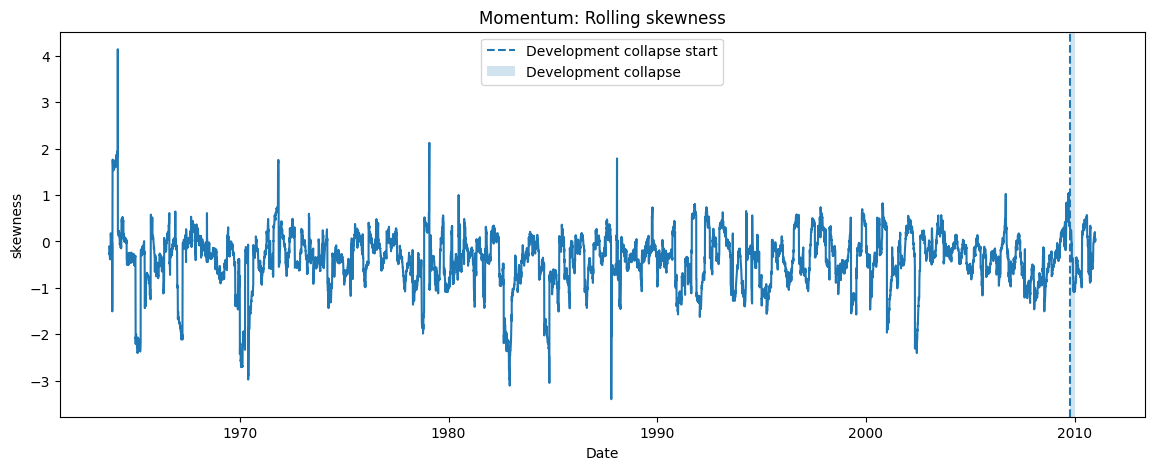

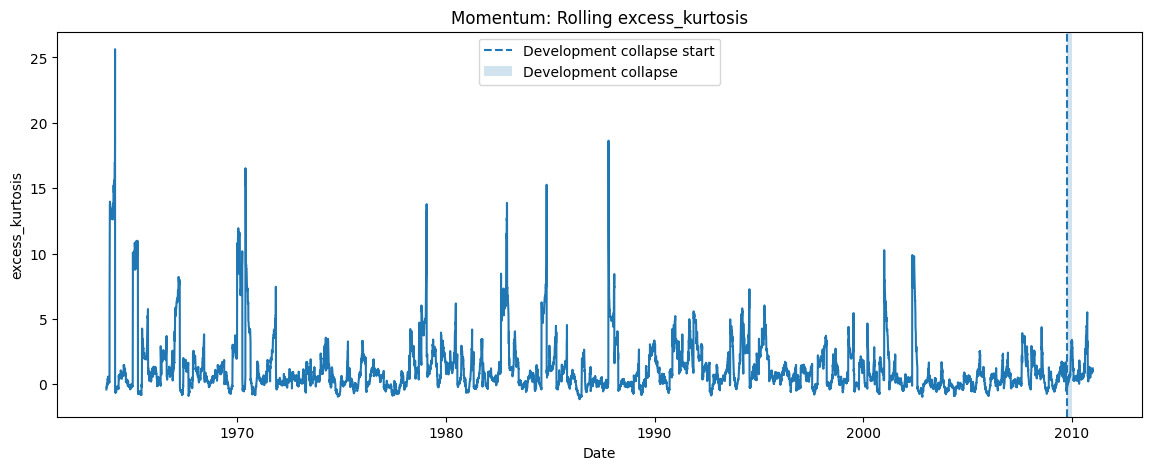

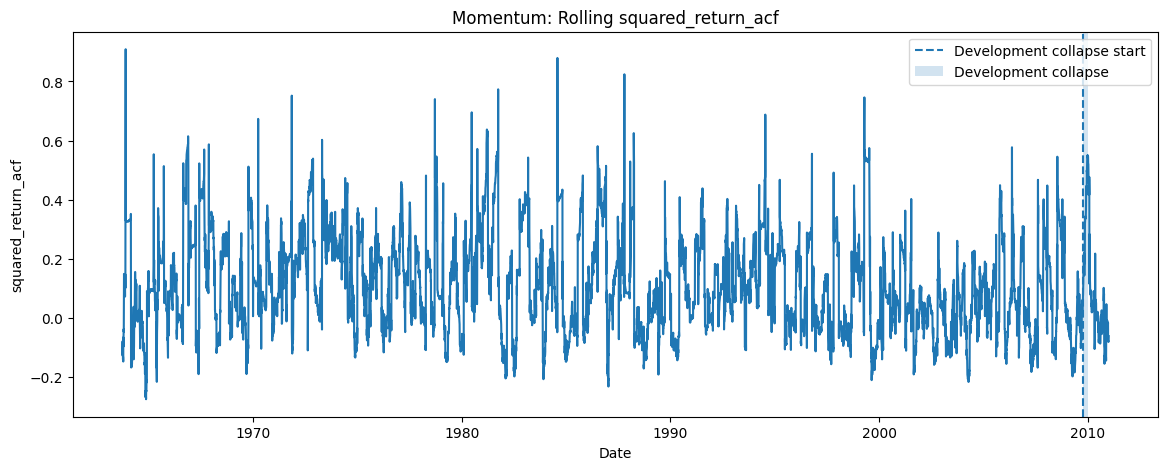

In [33]:
for diagnostic in raw_diagnostics.columns:
    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(
        raw_diagnostics.index,
        raw_diagnostics[diagnostic],
    )

    ax.axvline(
        DEVELOPMENT_COLLAPSE_START,
        linestyle="--",
        label="Development collapse start",
    )

    ax.axvspan(
        DEVELOPMENT_COLLAPSE_START,
        DEVELOPMENT_COLLAPSE_END,
        alpha=0.2,
        label="Development collapse",
    )

    ax.set_title(
        f"Momentum: Rolling {diagnostic}"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel(diagnostic)
    ax.legend()

    plt.show()

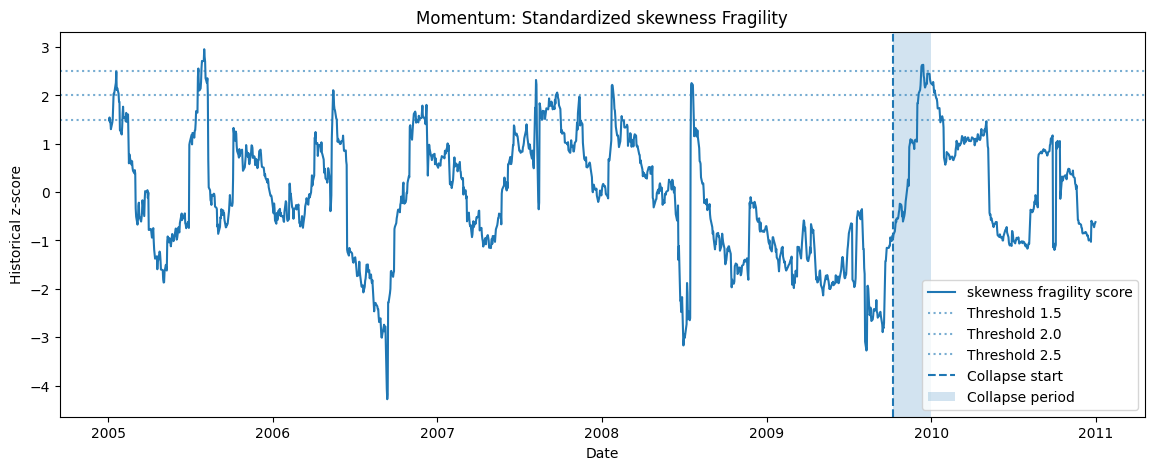

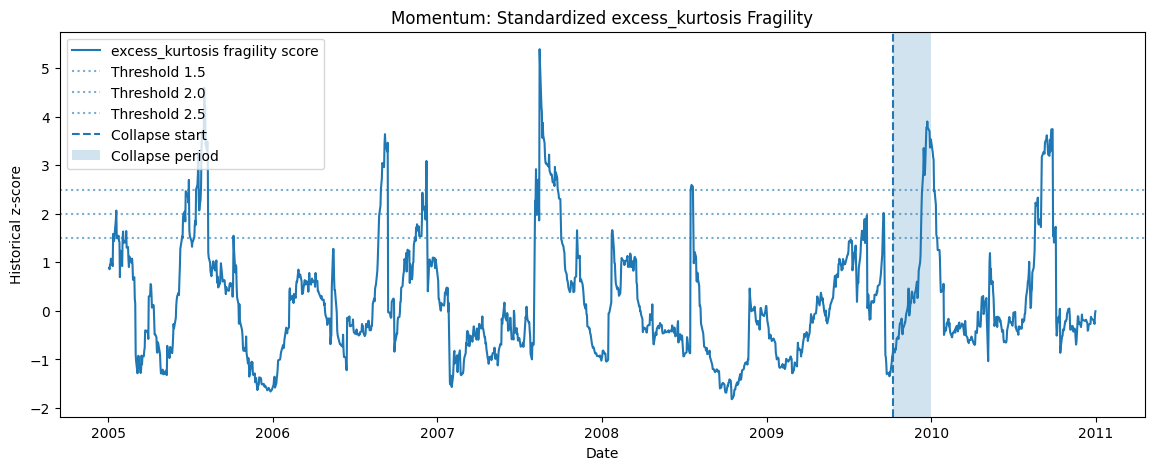

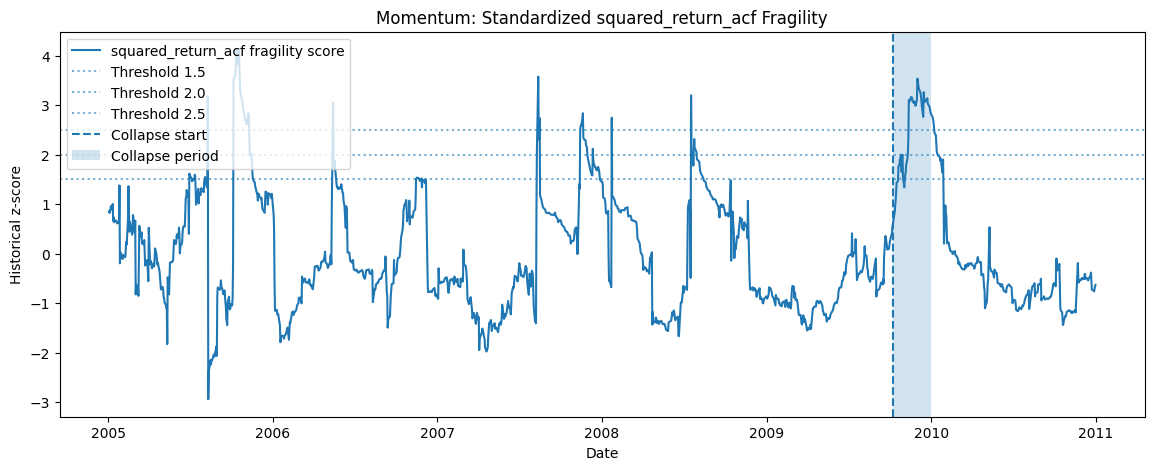

In [34]:
DISPLAY_START = pd.Timestamp("2005-01-01")
DISPLAY_END = pd.Timestamp("2010-12-31")

for diagnostic in fragility_scores.columns:
    fig, ax = plt.subplots(figsize=(14, 5))

    plotted = fragility_scores.loc[
        DISPLAY_START:DISPLAY_END,
        diagnostic,
    ]

    ax.plot(
        plotted.index,
        plotted,
        label=f"{diagnostic} fragility score",
    )

    for threshold in CANDIDATE_THRESHOLDS:
        ax.axhline(
            threshold,
            linestyle=":",
            alpha=0.6,
            label=f"Threshold {threshold}",
        )

    ax.axvline(
        DEVELOPMENT_COLLAPSE_START,
        linestyle="--",
        label="Collapse start",
    )

    ax.axvspan(
        DEVELOPMENT_COLLAPSE_START,
        DEVELOPMENT_COLLAPSE_END,
        alpha=0.2,
        label="Collapse period",
    )

    ax.set_title(
        f"Momentum: Standardized {diagnostic} Fragility"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Historical z-score")
    ax.legend()

    plt.show()



In [35]:
def extract_warning_events(
    warning_condition: pd.Series,
    reset_days: int = 5,
) -> pd.DatetimeIndex:
    """
    Extract distinct warning-event dates.

    A warning begins on the first True day. Another warning cannot begin
    until the condition has remained False for at least `reset_days`.
    """
    condition = (
        warning_condition
        .fillna(False)
        .astype(bool)
    )

    warning_dates = []
    active_warning = False
    false_run_length = reset_days

    for date, is_warning in condition.items():
        if is_warning:
            if (
                not active_warning
                and false_run_length >= reset_days
            ):
                warning_dates.append(date)

            active_warning = True
            false_run_length = 0

        else:
            if active_warning:
                false_run_length += 1

                if false_run_length >= reset_days:
                    active_warning = False
            else:
                false_run_length = min(
                    false_run_length + 1,
                    reset_days,
                )

    return pd.DatetimeIndex(warning_dates)

In [36]:
test_warning_condition = pd.Series(
    [
        False,
        True, True,
        False, False,
        True,
        False, False, False, False, False,
        True, True,
    ],
    index=pd.date_range(
        "2020-01-01",
        periods=13,
        freq="B",
    ),
)

test_warning_dates = extract_warning_events(
    test_warning_condition,
    reset_days=5,
)

expected_warning_dates = pd.DatetimeIndex(
    [
        test_warning_condition.index[1],
        test_warning_condition.index[11],
    ]
)

pd.testing.assert_index_equal(
    test_warning_dates,
    expected_warning_dates,
)

print("✓ Warning-event extraction test passed")

✓ Warning-event extraction test passed


In [37]:
collapse_start_position = momentum.index.get_loc(
    DEVELOPMENT_COLLAPSE_START
)

warning_window_start_position = max(
    0,
    collapse_start_position - WARNING_HORIZON,
)

WARNING_WINDOW_START = momentum.index[
    warning_window_start_position
]

print("Warning window:", WARNING_WINDOW_START.date())
print("Collapse start:", DEVELOPMENT_COLLAPSE_START.date())

def evaluate_development_warning(
    score: pd.Series,
    threshold: float,
    collapse_start: pd.Timestamp,
    warning_window_start: pd.Timestamp,
    reset_days: int,
) -> dict:
    """
    Evaluate one threshold against the development event.
    """
    warning_condition = score >= threshold

    warning_dates = extract_warning_events(
        warning_condition,
        reset_days=reset_days,
    )

    pre_collapse_warnings = warning_dates[
        (warning_dates >= warning_window_start)
        & (warning_dates < collapse_start)
    ]

    earlier_false_positives = warning_dates[
        warning_dates < warning_window_start
    ]

    if len(pre_collapse_warnings) > 0:
        first_qualifying_warning = (
            pre_collapse_warnings[0]
        )

        warning_position = score.index.get_loc(
            first_qualifying_warning
        )

        collapse_position = score.index.get_loc(
            collapse_start
        )

        lead_time = (
            collapse_position - warning_position
        )
    else:
        first_qualifying_warning = pd.NaT
        lead_time = np.nan

    return {
        "threshold": threshold,
        "detected": len(pre_collapse_warnings) > 0,
        "first_qualifying_warning": (
            first_qualifying_warning
        ),
        "lead_time_days": lead_time,
        "qualifying_warning_count": len(
            pre_collapse_warnings
        ),
        "earlier_false_positive_count": len(
            earlier_false_positives
        ),
        "total_warning_events": len(warning_dates),
    }

Warning window: 2009-04-08
Collapse start: 2009-10-07


In [38]:
development_results = []

for diagnostic in fragility_scores.columns:
    for threshold in CANDIDATE_THRESHOLDS:
        result = evaluate_development_warning(
            score=fragility_scores[diagnostic],
            threshold=threshold,
            collapse_start=DEVELOPMENT_COLLAPSE_START,
            warning_window_start=WARNING_WINDOW_START,
            reset_days=WARNING_RESET_DAYS,
        )

        result["diagnostic"] = diagnostic
        development_results.append(result)

development_results = pd.DataFrame(
    development_results
)

development_results = development_results[
    [
        "diagnostic",
        "threshold",
        "detected",
        "first_qualifying_warning",
        "lead_time_days",
        "qualifying_warning_count",
        "earlier_false_positive_count",
        "total_warning_events",
    ]
]

development_results.sort_values(
    [
        "diagnostic",
        "threshold",
    ]
)

,diagnostic,threshold,detected,first_qualifying_warning,lead_time_days,qualifying_warning_count,earlier_false_positive_count,total_warning_events
3,excess_kurtosis,1.5,True,2009-07-30,48.0,2,76,80
4,excess_kurtosis,2.0,True,2009-09-17,14.0,1,67,71
5,excess_kurtosis,2.5,False,NaT,NaN,0,60,62
0,skewness,1.5,False,NaT,NaN,0,74,75
1,skewness,2.0,False,NaT,NaN,0,49,50
2,skewness,2.5,False,NaT,NaN,0,29,30
6,squared_return_acf,1.5,False,NaT,NaN,0,91,92
7,squared_return_acf,2.0,False,NaT,NaN,0,66,67
8,squared_return_acf,2.5,False,NaT,NaN,0,49,50


In [39]:
def development_selection_score(
    row: pd.Series,
) -> float:
    """
    Rank candidate settings for development inspection.

    This is a transparent development heuristic, not a statistical test.
    """
    if not row["detected"]:
        return -np.inf

    lead_time_reward = min(
        float(row["lead_time_days"]),
        WARNING_HORIZON,
    ) / WARNING_HORIZON

    false_positive_penalty = (
        0.10
        * float(
            row["earlier_false_positive_count"]
        )
    )

    return (
        1.0
        + lead_time_reward
        - false_positive_penalty
    )

development_results["selection_score"] = (
    development_results.apply(
        development_selection_score,
        axis=1,
    )
)

development_results.sort_values(
    "selection_score",
    ascending=False,
)

,diagnostic,threshold,detected,first_qualifying_warning,lead_time_days,qualifying_warning_count,earlier_false_positive_count,total_warning_events,selection_score
4,excess_kurtosis,2.0,True,2009-09-17,14.0,1,67,71,-5.588889
3,excess_kurtosis,1.5,True,2009-07-30,48.0,2,76,80,-6.219048
0,skewness,1.5,False,NaT,NaN,0,74,75,-inf
2,skewness,2.5,False,NaT,NaN,0,29,30,-inf
1,skewness,2.0,False,NaT,NaN,0,49,50,-inf
5,excess_kurtosis,2.5,False,NaT,NaN,0,60,62,-inf
6,squared_return_acf,1.5,False,NaT,NaN,0,91,92,-inf
7,squared_return_acf,2.0,False,NaT,NaN,0,66,67,-inf
8,squared_return_acf,2.5,False,NaT,NaN,0,49,50,-inf


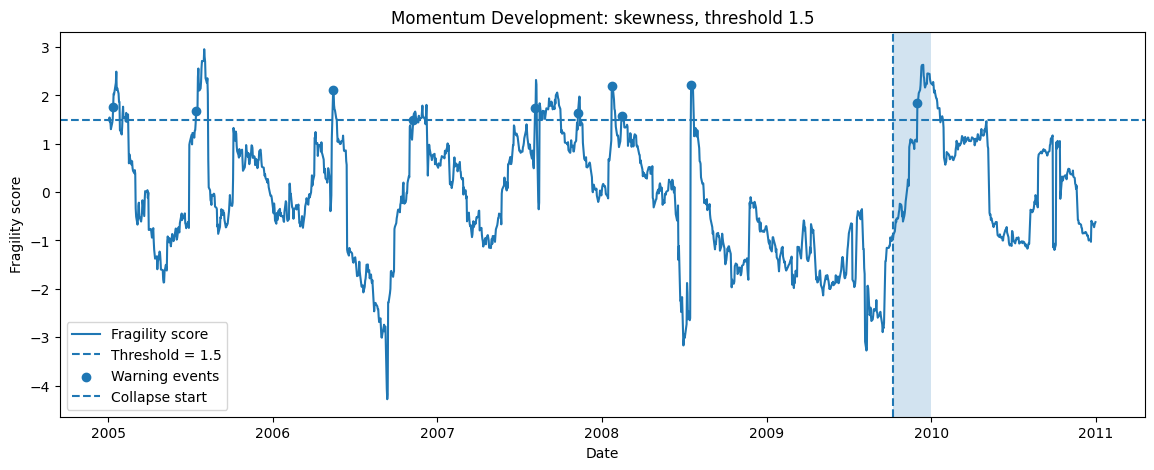

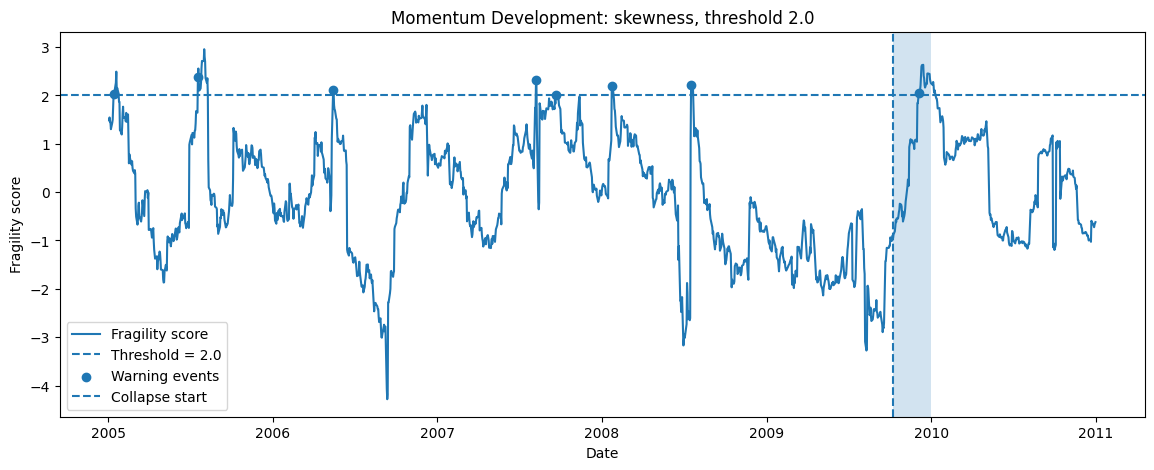

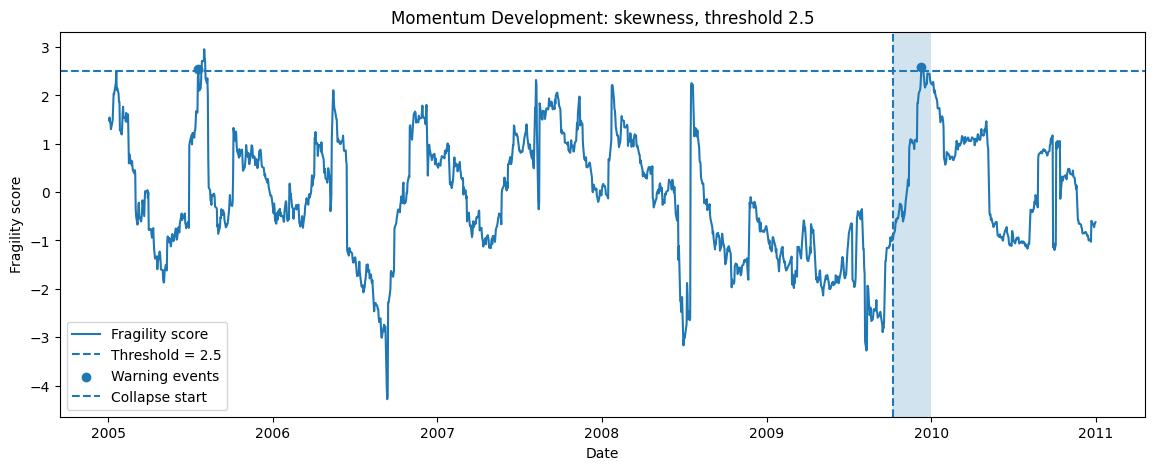

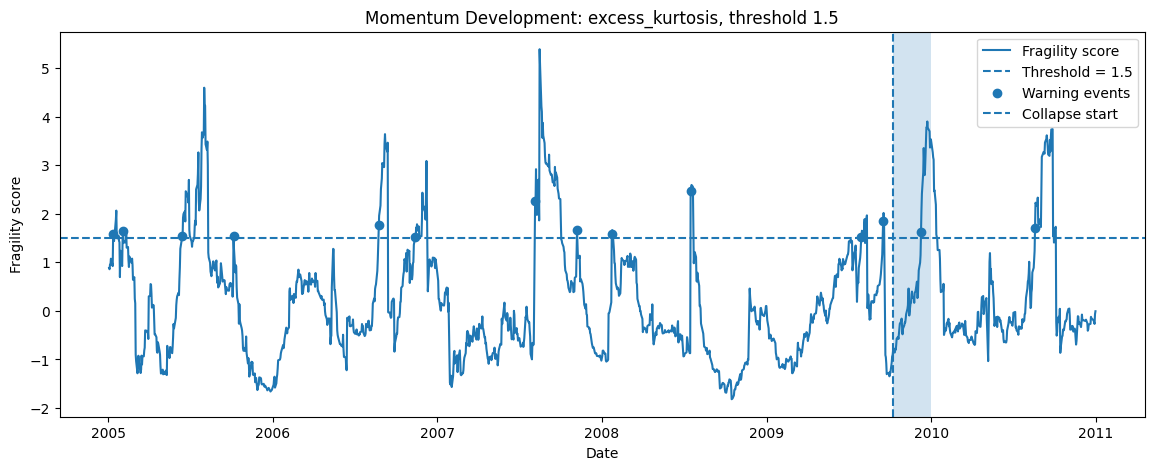

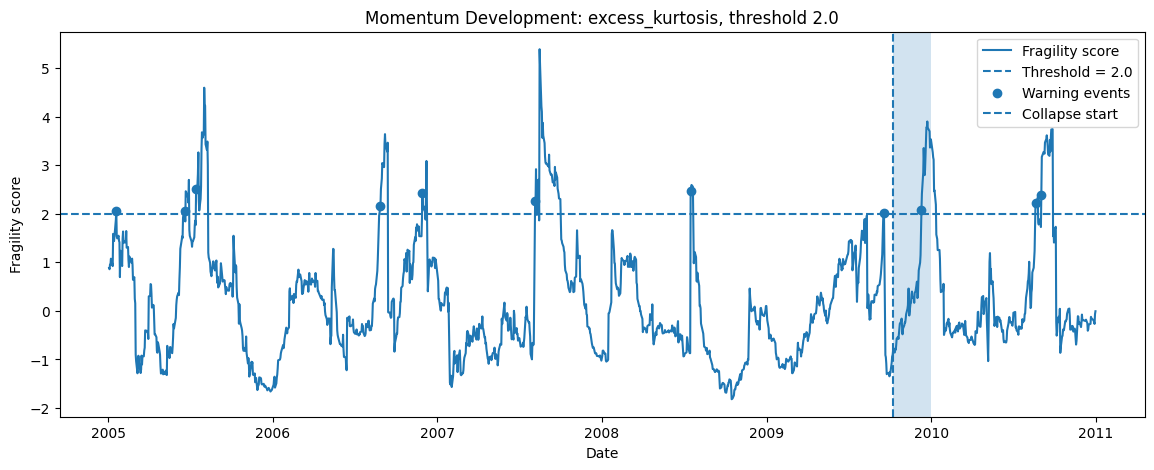

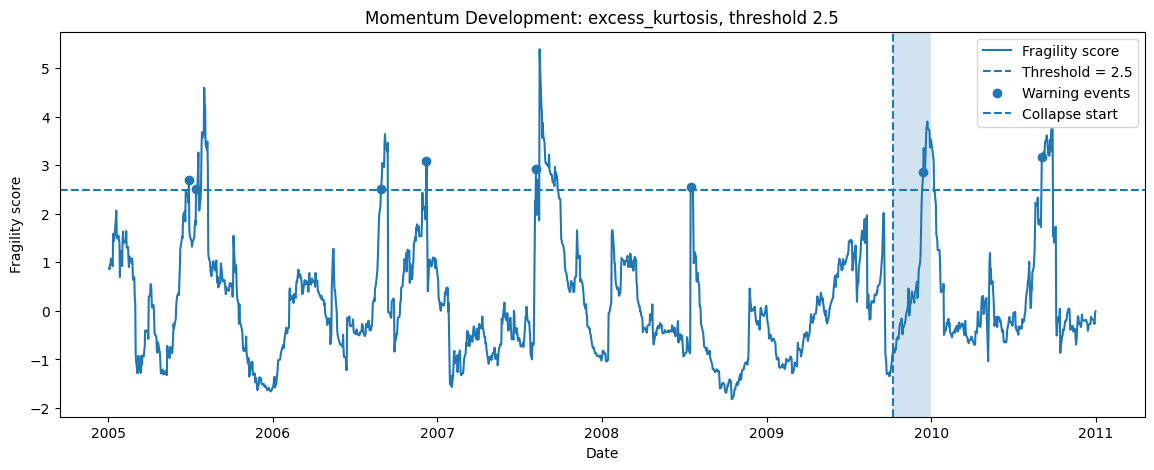

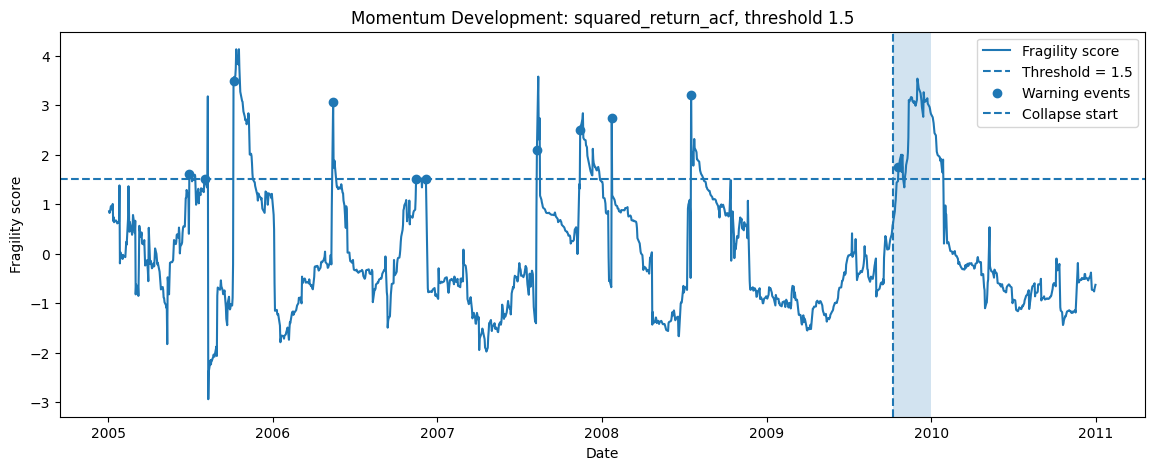

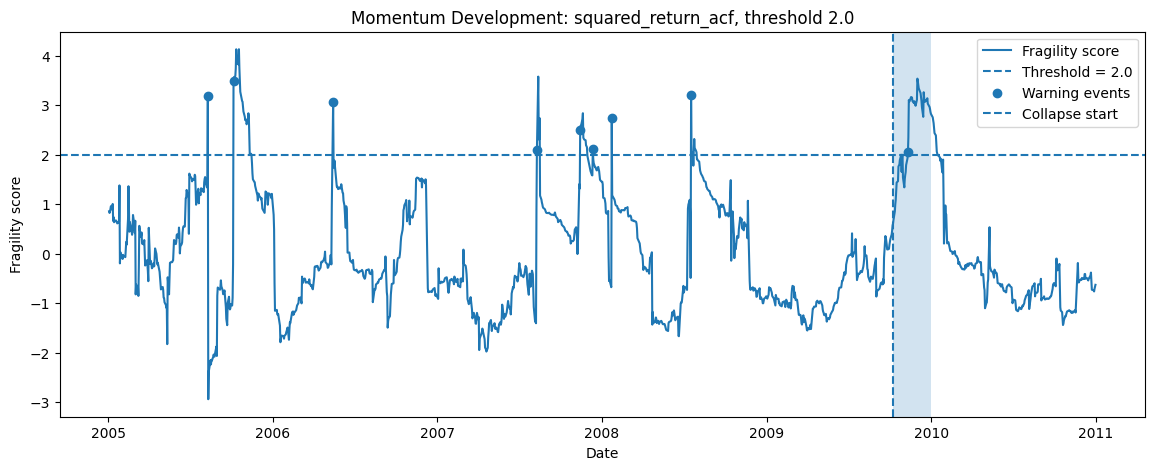

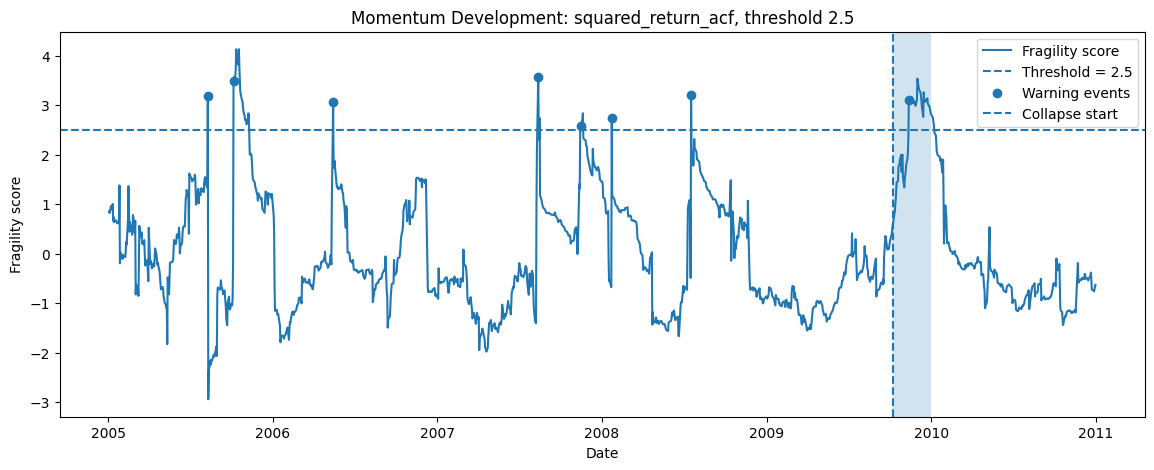

In [40]:
def plot_development_warnings(
    score: pd.Series,
    diagnostic: str,
    threshold: float,
) -> None:
    warning_dates = extract_warning_events(
        score >= threshold,
        reset_days=WARNING_RESET_DAYS,
    )

    fig, ax = plt.subplots(figsize=(14, 5))

    plotted = score.loc[
        DISPLAY_START:DISPLAY_END
    ]

    ax.plot(
        plotted.index,
        plotted,
        label="Fragility score",
    )

    ax.axhline(
        threshold,
        linestyle="--",
        label=f"Threshold = {threshold}",
    )

    visible_warning_dates = warning_dates[
        (warning_dates >= DISPLAY_START)
        & (warning_dates <= DISPLAY_END)
    ]

    visible_values = score.reindex(
        visible_warning_dates
    )

    ax.scatter(
        visible_warning_dates,
        visible_values,
        marker="o",
        label="Warning events",
    )

    ax.axvline(
        DEVELOPMENT_COLLAPSE_START,
        linestyle="--",
        label="Collapse start",
    )

    ax.axvspan(
        DEVELOPMENT_COLLAPSE_START,
        DEVELOPMENT_COLLAPSE_END,
        alpha=0.2,
    )

    ax.set_title(
        f"Momentum Development: {diagnostic}, "
        f"threshold {threshold}"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Fragility score")
    ax.legend()

    plt.show()

for diagnostic in fragility_scores.columns:
    for threshold in CANDIDATE_THRESHOLDS:
        plot_development_warnings(
            fragility_scores[diagnostic],
            diagnostic=diagnostic,
            threshold=threshold,
        )

In [41]:
def combined_warning_score(
    scores: pd.DataFrame,
    threshold: float,
) -> pd.Series:
    """
    Count how many diagnostics exceed the same z-score threshold.
    """
    return (
        scores >= threshold
    ).sum(axis=1)

combination_results = []

for threshold in CANDIDATE_THRESHOLDS:
    diagnostic_count = combined_warning_score(
        fragility_scores,
        threshold=threshold,
    )

    warning_condition = diagnostic_count >= 2

    warning_dates = extract_warning_events(
        warning_condition,
        reset_days=WARNING_RESET_DAYS,
    )

    pre_collapse = warning_dates[
        (warning_dates >= WARNING_WINDOW_START)
        & (
            warning_dates
            < DEVELOPMENT_COLLAPSE_START
        )
    ]

    earlier_false_positives = warning_dates[
        warning_dates < WARNING_WINDOW_START
    ]

    if len(pre_collapse) > 0:
        first_warning = pre_collapse[0]

        lead_time = (
            momentum.index.get_loc(
                DEVELOPMENT_COLLAPSE_START
            )
            - momentum.index.get_loc(
                first_warning
            )
        )
    else:
        first_warning = pd.NaT
        lead_time = np.nan

    combination_results.append(
        {
            "rule": "at_least_2_of_3",
            "threshold": threshold,
            "detected": len(pre_collapse) > 0,
            "first_qualifying_warning": first_warning,
            "lead_time_days": lead_time,
            "earlier_false_positive_count": len(
                earlier_false_positives
            ),
            "total_warning_events": len(
                warning_dates
            ),
        }
    )

combination_results = pd.DataFrame(
    combination_results
)

combination_results

,rule,threshold,detected,first_qualifying_warning,lead_time_days,earlier_false_positive_count,total_warning_events
0,at_least_2_of_3,1.5,False,NaT,NaN,68,69
1,at_least_2_of_3,2.0,False,NaT,NaN,48,49
2,at_least_2_of_3,2.5,False,NaT,NaN,30,31


In [42]:
RAW_DIAGNOSTIC_OUTPUT = (
    RESULTS
    / "momentum_development_raw_diagnostics.parquet"
)

FRAGILITY_SCORE_OUTPUT = (
    RESULTS
    / "momentum_development_fragility_scores.parquet"
)

DEVELOPMENT_RESULTS_OUTPUT = (
    RESULTS
    / "momentum_development_threshold_results.csv"
)

COMBINATION_RESULTS_OUTPUT = (
    RESULTS
    / "momentum_development_combination_results.csv"
)

raw_diagnostics.to_parquet(
    RAW_DIAGNOSTIC_OUTPUT
)

fragility_scores.to_parquet(
    FRAGILITY_SCORE_OUTPUT
)

development_results.to_csv(
    DEVELOPMENT_RESULTS_OUTPUT,
    index=False,
)

combination_results.to_csv(
    COMBINATION_RESULTS_OUTPUT,
    index=False,
)

print("✓ Development outputs saved")

✓ Development outputs saved


## Candidate disclosure

The following candidates were evaluated on the Momentum development case:

- Three diagnostics:
  - rolling skewness,
  - rolling excess kurtosis,
  - rolling autocorrelation of squared returns.
- One 63-trading-day diagnostic window.
- One 252-observation trailing z-score reference window.
- Three warning thresholds:
  - 1.5,
  - 2.0,
  - 2.5.
- One combination rule:
  - at least two of three diagnostics above the same threshold.

All candidates will be reported, including candidates that fail to detect the
development collapse.

In [43]:
FROZEN_DIAGNOSTIC_CONFIG = {
    "factor_used_for_development": "MOM",
    "development_collapse_start": "2009-10-07",

    "diagnostic_window": 63,
    "zscore_reference_window": 252,

    "selected_rule_type": "single_diagnostic",
    "selected_diagnostics": [
        "excess_kurtosis"
    ],

    "warning_threshold": 2.0,

    "warning_direction": {
        "skewness": "negative",
        "excess_kurtosis": "positive",
        "squared_return_acf": "positive",
    },

    "combination_requirement": None,

    "warning_reset_days": 5,
    "warning_to_collapse_horizon_days": 126,

    "causal_standardization": True,
    "reference_shift_days": 1,

    "development_first_warning": "2009-09-17",
    "development_lead_time_days": 14,

    "development_selection_rationale":
        (
            "Only excess kurtosis detected the development collapse. "
            "A threshold of 2.0 was selected because it detected the "
            "event while generating fewer warning events than 1.5. "
            "The 2-of-3 combination rule and the remaining individual "
            "diagnostics failed to detect the development collapse."
        ),

    "status": "FROZEN",
}

In [44]:
assert FROZEN_DIAGNOSTIC_CONFIG[
    "status"
] in {
    "DRAFT_NOT_FROZEN",
    "FROZEN",
}

assert FROZEN_DIAGNOSTIC_CONFIG[
    "diagnostic_window"
] == DIAGNOSTIC_WINDOW

assert FROZEN_DIAGNOSTIC_CONFIG[
    "zscore_reference_window"
] == ZSCORE_REFERENCE_WINDOW

if (
    FROZEN_DIAGNOSTIC_CONFIG["status"]
    == "FROZEN"
):
    assert (
        FROZEN_DIAGNOSTIC_CONFIG[
            "warning_threshold"
        ]
        in CANDIDATE_THRESHOLDS
    )

    assert len(
        FROZEN_DIAGNOSTIC_CONFIG[
            "selected_diagnostics"
        ]
    ) >= 1

print("✓ Diagnostic configuration passed validation")

✓ Diagnostic configuration passed validation


In [45]:
FROZEN_CONFIG_OUTPUT = (
    RESULTS
    / "frozen_diagnostic_parameters.json"
)

with open(
    FROZEN_CONFIG_OUTPUT,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        FROZEN_DIAGNOSTIC_CONFIG,
        file,
        indent=2,
        sort_keys=True,
    )

print("Saved:", FROZEN_CONFIG_OUTPUT)

with open(
    FROZEN_CONFIG_OUTPUT,
    "r",
    encoding="utf-8",
) as file:
    frozen_config_reload = json.load(file)

assert (
    frozen_config_reload
    == FROZEN_DIAGNOSTIC_CONFIG
)

print("✓ Frozen configuration reloads exactly")

Saved: /content/drive/MyDrive/When_Do_Factor_Premia_Break/data/results/frozen_diagnostic_parameters.json
✓ Frozen configuration reloads exactly


In [46]:
print("=" * 70)
print("MOMENTUM DEVELOPMENT DIAGNOSTICS COMPLETE")
print("=" * 70)

print(
    "Development collapse:",
    DEVELOPMENT_COLLAPSE_START.date(),
)

print(
    "Diagnostic window:",
    DIAGNOSTIC_WINDOW,
)

print(
    "Z-score reference window:",
    ZSCORE_REFERENCE_WINDOW,
)

print(
    "Candidate thresholds:",
    CANDIDATE_THRESHOLDS,
)

print(
    "Configuration status:",
    FROZEN_DIAGNOSTIC_CONFIG["status"],
)

print("\nSaved outputs:")

for path in [
    RAW_DIAGNOSTIC_OUTPUT,
    FRAGILITY_SCORE_OUTPUT,
    DEVELOPMENT_RESULTS_OUTPUT,
    COMBINATION_RESULTS_OUTPUT,
    FROZEN_CONFIG_OUTPUT,
]:
    print(" -", path.name)

MOMENTUM DEVELOPMENT DIAGNOSTICS COMPLETE
Development collapse: 2009-10-07
Diagnostic window: 63
Z-score reference window: 252
Candidate thresholds: [1.5, 2.0, 2.5]
Configuration status: FROZEN

Saved outputs:
 - momentum_development_raw_diagnostics.parquet
 - momentum_development_fragility_scores.parquet
 - momentum_development_threshold_results.csv
 - momentum_development_combination_results.csv
 - frozen_diagnostic_parameters.json


## Development Summary

Three candidate diagnostics and one predefined combination rule were evaluated
on the Momentum development episode.

Findings:

- Rolling skewness did not detect the development collapse.
- Rolling squared-return autocorrelation did not detect the development collapse.
- The predefined 2-of-3 combination rule did not detect the development collapse.
- Rolling excess kurtosis detected the development collapse at thresholds of
  1.5 and 2.0.
- A threshold of 2.0 was selected because it detected the development event
  while producing fewer warning events than the 1.5 threshold.

The diagnostic specification is now frozen and will be applied unchanged to all
remaining factor holdout evaluations.